# Credit Card Repayment Default Predictor - Training Model

In [12]:
import tensorflow as tf
import pickle
import numpy as np


In [13]:
with open('bootstrapped_data.pkl' , 'rb') as f:
    x_train, y_train, x_val, y_val, x_test, y_test  = pickle.load(f)

In [14]:
x_train.shape, y_train.shape, x_val.shape, y_val.shape, x_test.shape, y_test.shape

((100000, 23), (100000, 1), (4800, 23), (4800, 1), (6000, 23), (6000, 1))

In [15]:
n_inputs = x_train.shape[1]
batch_size = 32
epochs = 50

In [16]:
hl1 = 64
hl2 = 32

In [17]:
model = tf.keras.Sequential([
    tf.keras.layers.InputLayer(input_shape=(n_inputs,)),
    tf.keras.layers.Dense(hl1, activation='elu'),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(hl2, activation='elu'),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

/home/tru_exe/projects/MLwinterARC25/.venv/lib/python3.12/site-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


In [18]:
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

In [19]:
train_x = np.asarray(x_train, dtype=np.float32)
train_y = np.asarray(y_train, dtype=np.float32)
val_x = np.asarray(x_val, dtype=np.float32)
val_y = np.asarray(y_val, dtype=np.float32)
test_x = np.asarray(x_test, dtype=np.float32)
test_y = np.asarray(y_test, dtype=np.float32)

In [24]:
es = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

In [25]:
import matplotlib.pyplot as plt

Epoch 1/50
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.7095 - loss: 0.5578 - val_accuracy: 0.7694 - val_loss: 0.5574
Epoch 2/50
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.7111 - loss: 0.5561 - val_accuracy: 0.7646 - val_loss: 0.5579
Epoch 3/50
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.7122 - loss: 0.5551 - val_accuracy: 0.7673 - val_loss: 0.5577
Epoch 4/50
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.7138 - loss: 0.5535 - val_accuracy: 0.7706 - val_loss: 0.5547
Epoch 5/50
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.7136 - loss: 0.5519 - val_accuracy: 0.7554 - val_loss: 0.5631
Epoch 6/50
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.7143 - loss: 0.5507 - val_accuracy: 0.7571 - val_loss: 0.5694
Epoch 7/50
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.7156 - loss: 0.5503 - val_accuracy: 0.7544 - val_loss: 0.5574
Epoch 8/50
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.7165 - loss: 0.5496 - 

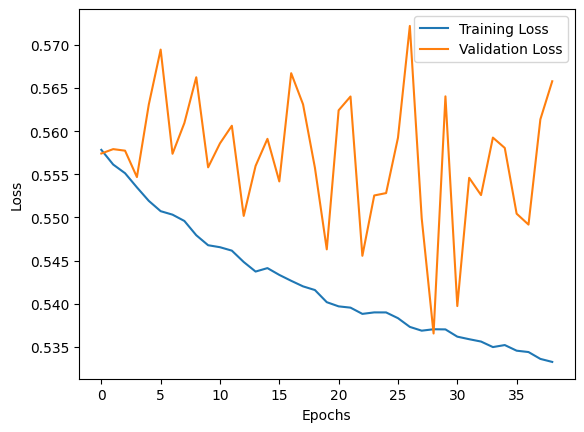

In [26]:
history = model.fit(train_x, train_y,
                    validation_data=(val_x, val_y),
                    epochs=epochs,
                    batch_size=batch_size,
                    callbacks=[es],
                    verbose=1)

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [30]:
model.save('credit_default_model.keras')

In [27]:
test_loss, test_accuracy = model.evaluate(test_x, test_y, verbose=0)
print(f'Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}')

Test Loss: 0.5374, Test Accuracy: 0.7605


In [28]:
best_epoch = np.argmin(history.history['val_loss']) + 1
best_val_loss = np.min(history.history['val_loss'])
print(f'Best Epoch: {best_epoch}')
print(f'Best Validation Loss: {best_val_loss:.4f}')

Best Epoch: 29
Best Validation Loss: 0.5366


The model achieved its minimum validation loss at epoch 29, after which overfitting began. Early stopping restored the weights from this epoch.

## ROC-AUC and other metrics

In [34]:
from sklearn.metrics import roc_auc_score , roc_curve

3125/3125 ━━━━━━━━━━━━━━━━━━━━ 3s 994us/step
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Train AUC: 0.820
Val AUC: 0.768


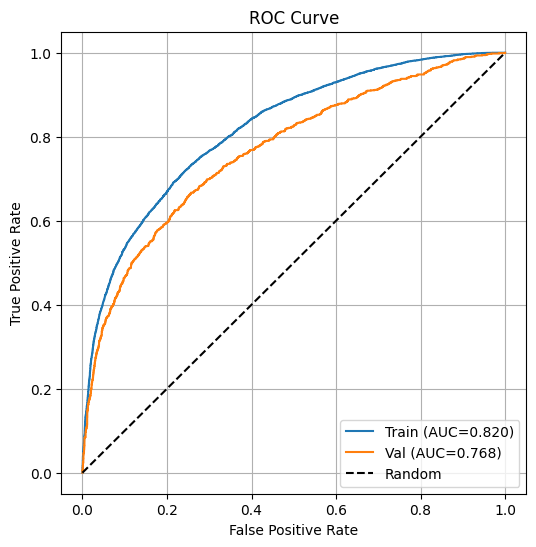

In [35]:
y_train_pred = model.predict(train_x).ravel()
y_val_pred   = model.predict(val_x).ravel()

# AUC (your code)
train_auc = roc_auc_score(y_train, y_train_pred)
val_auc   = roc_auc_score(y_val, y_val_pred)

print(f"Train AUC: {train_auc:.3f}")
print(f"Val AUC: {val_auc:.3f}")

# ROC curve points
fpr_tr, tpr_tr, _ = roc_curve(y_train, y_train_pred)
fpr_va, tpr_va, _ = roc_curve(y_val,   y_val_pred)

# Plot
plt.figure(figsize=(6, 6))
plt.plot(fpr_tr, tpr_tr, label=f"Train (AUC={train_auc:.3f})")
plt.plot(fpr_va, tpr_va, label=f"Val (AUC={val_auc:.3f})")
plt.plot([0, 1], [0, 1], "k--", label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()